# Create Training Labels from the Critical Mineral Deposits Database

In [69]:
import os
import numpy as np
import geopandas as gpd
from pathlib import Path

import sys
if sys.version_info < (3, 9):
    from importlib_resources import files
else:
    from importlib.resources import files

from beak.utilities.io import load_dataset
from beak.utilities.conversions import create_binary_raster

import numpy as np
import pandas as pd
from shapely.geometry import shape
from shapely.wkt import loads
import rasterio


# Definitions

In [70]:
# Set base paths and files
BASE_PATH = files("beak.data")

EPSG_CODE = 102008
RESOLUTION = 500
BASE_SPATIAL = str(EPSG_CODE) + "_" + str(RESOLUTION)
BASE_EXTENT = "poco_southwest"

BASE_RASTER = BASE_PATH / "BASE_RASTERS" / str("EPSG_" + str(EPSG_CODE) + "_RES_" + str(RESOLUTION) + "_" + BASE_EXTENT + ".tif")
base_raster = rasterio.open(BASE_RASTER)

# Points file and query to select relevant mineral occurences
PATH_LABELS = BASE_PATH / "RAW" / "mineral_deposits" / "Porphyry_Copper" / "TA2_Pre_Hack_12M" / "set_20240609" / "copper_mineral_site_data.csv"
PATH_LABELS_PCU = BASE_PATH / "RAW" / "mineral_deposits" / "Porphyry_Copper" / "Dicken_US" / "pCu_deps_pros.shp"
SQL_QUERY = "country == 'United States'"

# Set the output file
PATH_ROOT = BASE_PATH / "PROCESSED" / str("regional" + "_" + BASE_EXTENT + "_" + BASE_SPATIAL)
PATH_EXPORT = PATH_ROOT / "labels" / str("TA2_240609_FILTERED_HM9_PCUDEPPRO" + ".tif")
OUT_FILE = PATH_EXPORT
OUT_GPKT = str(PATH_LABELS.parent / str(PATH_LABELS.stem)) + ".gpkg"

print(f"Output file: {OUT_FILE}")


Output file: S:\Projekte\20230082_DARPA_CriticalMAAS_TA3\Bearbeitung\GitHub\beak-ta3\src\beak\data\PROCESSED\regional_102008_500_poco_southwest\labels\TA2_240609_FILTERED_HM9_PCUDEPPRO.tif


# **Helper**

In [71]:
import matplotlib.pyplot as plt
def plot_histogram(df, column, num_bins=100):
    df['top1_deposit_classification_confidence'].hist(bins=num_bins)
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.title(f"Histogram of {column}")
    plt.show()

In [72]:
def count_values(df, column):    
    values = df[column].unique()
    values_df = pd.DataFrame(values, columns=[column])
    counts = df[column].value_counts()
    values_with_counts = counts.reset_index()
    values_with_counts.columns = [column, 'count']
    
    return values_with_counts


# **Load and initially clean data**

In [73]:
mineral_sites = gpd.read_file(PATH_LABELS)

mineral_sites = load_dataset(PATH_LABELS).query(SQL_QUERY)
mineral_sites = mineral_sites.dropna(subset=["loc_wkt"])
mineral_sites["geometry"] = mineral_sites["loc_wkt"].apply(loads)
mineral_sites = gpd.GeoDataFrame(mineral_sites, geometry="geometry")
mineral_sites = mineral_sites.explode(ignore_index=True)
mineral_sites = mineral_sites.drop_duplicates(subset=["geometry"])
mineral_sites = mineral_sites.set_crs("EPSG:4326")

mineral_sites

,group_id,ms,ms_name,ms_type,ms_rank,country,state_or_province,loc_crs,loc_wkt,top1_deposit_type,top1_deposit_group,top1_deposit_environment,top1_deposit_classification_confidence,top1_deposit_classification_source,geometry
0,3,https://minmod.isi.edu/resource/site__api-cdr-...,NI 43-101 Technical Report for the Gabbs Proje...,NaN,NaN,United States,Nevada,EPSG:4326,POINT(417582 4292950),Porphyry copper- molybdenum,Porphyry,Magmatic hydrothermal,0.25000,Inferlink Extraction v2,POINT (417582.00000 4292950.00000)
1,34,https://minmod.isi.edu/resource/site__api-cdr-...,NI 43-101 Technical Report for the Whistler Pr...,NaN,NaN,United States,Alaska,EPSG:4326,POINT(-150.0 61.0),Porphyry copper Â± gold,Porphyry,Magmatic hydrothermal,0.50000,Inferlink Extraction v2,POINT (-150.00000 61.00000)
2,82,https://minmod.isi.edu/resource/site__api-cdr-...,NI 43-101 Technical Report for the Nokomis Pro...,NaN,NaN,United States,Minnesota,EPSG:4326,POINT(-91.5035 47.9716),U-M layered intrusion nickel- copper-PGE,Ultramafic and (or) mafic-layered intrusion,Magmatic,0.12833,"algorithm predictions, SRI deposit type classi...",POINT (-91.50350 47.97160)
3,101,https://minmod.isi.edu/resource/site__api-cdr-...,NI 43-101 Technical Report for the Back Forty ...,NaN,NaN,United States,Michigan,EPSG:4326,POINT(-87.6189 45.4133),MVT zinc-lead,Mississippi Valley- type (MVT),Basin hydrothermal,0.08481,"algorithm predictions, SRI deposit type classi...",POINT (-87.61890 45.41330)
4,164,['https://minmod.isi.edu/resource/site__api-cd...,['NI 43-101 Technical Report for the Pebble Pr...,NaN,NaN,United States,Alaska,EPSG:4326,GEOMETRYCOLLECTION (POINT (-154.31499999999999...,Porphyry copper Â± gold,Porphyry,Magmatic hydrothermal,1.00000,Inferlink Extraction v2,POINT (-154.31500 59.74600)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25867,50176,https://minmod.isi.edu/resource/site__mrdata-u...,Northern Light,Past Producer,D,United States,Nevada,EPSG:4326,POINT (-117.02954 40.6049),Fluvial placer gemstones,Placer,Erosional,0.18999,"algorithm predictions, SRI deposit type classi...",POINT (-117.02954 40.60490)
25868,50177,https://minmod.isi.edu/resource/site__mrdata-u...,Liberty Bell,Past Producer,D,United States,Nevada,EPSG:4326,POINT (-114.79979 41.77491),Supergene silver,Supergene,Supergene,0.23172,"algorithm predictions, SRI deposit type classi...",POINT (-114.79979 41.77491)
25869,2773,https://minmod.isi.edu/resource/site__mrdata-u...,"['Florence', 'Florence Conoco']",Prospect,A,United States,Arizona,EPSG:4326,POINT (-111.43072 33.04785),Porphyry copper- molybdenum,Porphyry,Magmatic hydrothermal,0.82008,"algorithm predictions, SRI deposit type classi...",POINT (-111.43072 33.04785)
25870,44105,['https://minmod.isi.edu/resource/site__10-538...,Twin Buttes,Past Producer,A,United States,Arizona,EPSG:4326,POINT (-111.05069 31.90822),Porphyry copper- molybdenum,Porphyry,Magmatic hydrothermal,0.89019,"algorithm predictions, SRI deposit type classi...",POINT (-111.05069 31.90822)


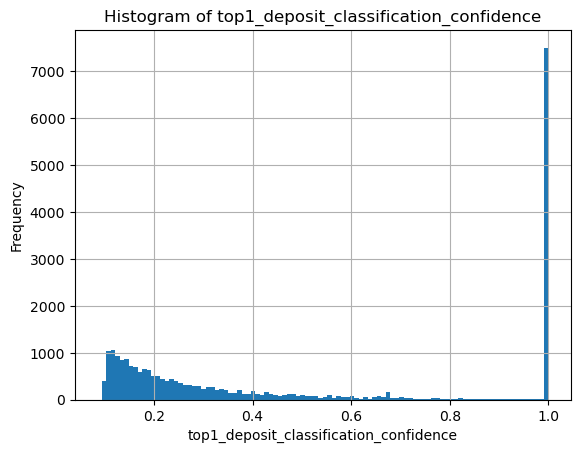

In [74]:
plot_histogram(mineral_sites, "top1_deposit_classification_confidence")

# Export to GeoPackages

## Filtered Points

In [75]:
query = "top1_deposit_type in ('Porphyry copper ± gold','Porphyry copper- molybdenum') and top1_deposit_classification_confidence >= 0.5 and ms_type in ('Past Producer', 'Prospect', 'Producer') and ms_rank in ('A', 'B', 'C')"

mineral_sites_filtered = mineral_sites.query(query)
mineral_sites_filtered

,group_id,ms,ms_name,ms_type,ms_rank,country,state_or_province,loc_crs,loc_wkt,top1_deposit_type,top1_deposit_group,top1_deposit_environment,top1_deposit_classification_confidence,top1_deposit_classification_source,geometry
68,878,['https://minmod.isi.edu/resource/site__mrdata...,"['Squaw Peak', 'Squaw Peak Mine']",Past Producer,A,United States,Arizona,EPSG:4326,GEOMETRYCOLLECTION (POINT (-111.85711999999999...,Porphyry copper- molybdenum,Porphyry,Magmatic hydrothermal,1.00000,"algorithm predictions, SRI crosswalk agent v0",POINT (-111.85712 34.48255)
69,878,['https://minmod.isi.edu/resource/site__mrdata...,"['Squaw Peak', 'Squaw Peak Mine']",Past Producer,A,United States,Arizona,EPSG:4326,GEOMETRYCOLLECTION (POINT (-111.85711999999999...,Porphyry copper- molybdenum,Porphyry,Magmatic hydrothermal,1.00000,"algorithm predictions, SRI crosswalk agent v0",POINT (-111.86528 34.48028)
313,1127,['https://minmod.isi.edu/resource/site__mrdata...,"['Tyrone', 'Tyrone Mine']",Producer,A,United States,New Mexico,EPSG:4326,GEOMETRYCOLLECTION (POINT (-108.37283999999999...,Porphyry copper- molybdenum,Porphyry,Magmatic hydrothermal,1.00000,"algorithm predictions, SRI crosswalk agent v0",POINT (-108.37284 32.64040)
314,1127,['https://minmod.isi.edu/resource/site__mrdata...,"['Tyrone', 'Tyrone Mine']",Producer,A,United States,New Mexico,EPSG:4326,GEOMETRYCOLLECTION (POINT (-108.37283999999999...,Porphyry copper- molybdenum,Porphyry,Magmatic hydrothermal,1.00000,"algorithm predictions, SRI crosswalk agent v0",POINT (-108.37312 32.63622)
1513,2580,https://minmod.isi.edu/resource/site__mrdata-u...,"['Cyprus Miami', 'Inspiration']",Producer,A,United States,Arizona,EPSG:4326,POINT (-110.88679 33.40818),Porphyry copper- molybdenum,Porphyry,Magmatic hydrothermal,1.00000,"algorithm predictions, SRI crosswalk agent v0",POINT (-110.88679 33.40818)
3765,5190,['https://minmod.isi.edu/resource/site__mrdata...,"['Copper Cities & Diamond H', 'Diamond H Mine']",Past Producer,A,United States,Arizona,EPSG:4326,GEOMETRYCOLLECTION (POINT (-110.88209000000000...,Porphyry copper- molybdenum,Porphyry,Magmatic hydrothermal,1.00000,"algorithm predictions, SRI crosswalk agent v0",POINT (-110.88209 33.44588)
3766,5190,['https://minmod.isi.edu/resource/site__mrdata...,"['Copper Cities & Diamond H', 'Diamond H Mine']",Past Producer,A,United States,Arizona,EPSG:4326,GEOMETRYCOLLECTION (POINT (-110.88209000000000...,Porphyry copper- molybdenum,Porphyry,Magmatic hydrothermal,1.00000,"algorithm predictions, SRI crosswalk agent v0",POINT (-110.91736 33.43341)
3891,5343,https://minmod.isi.edu/resource/site__mrdata-u...,"['Alvenco, Inc.', 'Dog']",Prospect,C,United States,Alaska,EPSG:4326,POINT (-136.26321 58.97333),Porphyry copper- molybdenum,Porphyry,Magmatic hydrothermal,0.52738,"algorithm predictions, SRI deposit type classi...",POINT (-136.26321 58.97333)
4018,5459,['https://minmod.isi.edu/resource/site__mrdata...,Peternie,Prospect,B,United States,Alaska,EPSG:4326,GEOMETRYCOLLECTION (POINT (-142.76937000000000...,Porphyry copper- molybdenum,Porphyry,Magmatic hydrothermal,1.00000,"algorithm predictions, SRI crosswalk agent v0",POINT (-142.76937 63.61163)
4019,5459,['https://minmod.isi.edu/resource/site__mrdata...,Peternie,Prospect,B,United States,Alaska,EPSG:4326,GEOMETRYCOLLECTION (POINT (-142.76937000000000...,Porphyry copper- molybdenum,Porphyry,Magmatic hydrothermal,1.00000,"algorithm predictions, SRI crosswalk agent v0",POINT (-142.99267 63.60972)


In [76]:
# Export filtered mineral sites
mineral_sites_filtered.to_file(OUT_GPKT, layer="mineral_sites_filtered", driver="GPKG", overwrite=True)


## Add PCU DepPro Data

In [77]:
# Labels MC
labels_pcu = gpd.read_file(PATH_LABELS_PCU)
labels_pcu = labels_pcu.to_crs(mineral_sites.crs)
labels_pcu


,GMRAP_ID,Coded_ID,Tract_name,Name,Name_other,Name_group,Includes,SiteStatus,Country,State_Prov,...,Comments,Minerals,Assd_rock,Dev_Status,Ref_list,Setting,Study_area,Short_ref,Strat_age,geometry
0,3322,003pCu9006x,Western U.S. and Sonoran Desert Jurassic Arc,Afterthought,Benway,None,Afterthought North and South,prospect,United States,Nevada,...,Porphyry-related copper skarn about 30 km NE o...,None,None,Occurrence,Wendt and Albino (1992); Satkoski and others (...,mixed,United States,U.S. Geological Survey National Mineral Resour...,Jurassic,POINT (-118.77815 39.16506)
1,3369,003pCu5003,Yukon-Tanana Upland,Airplane Ridge,None,None,None,prospect,United States,Alaska,...,"Biotite gneiss, amphibolite, and minor marble ...","chalcopyrite, magnetite, molybdenite, pyrite",None,Prospect,U.S. Geological Survey (2014a); Dashevsky and ...,continental margin,United States,U.S. Geological Survey National Mineral Resour...,Early Cretaceous,POINT (-143.93120 64.22870)
2,74,003pCu3006x,Western Mexican Basin and Range and Laramide S...,Ajo,New Cornelia,None,None,deposit,United States,Arizona,...,Exposed.,"albite, alunite, anhydrite/gypsum, biotite, ba...","andesite dike, andesite porphyry dike, quartz ...",Occurrence,"Cox, Force and others (2006); Dixon (1966); Gi...",continental margin,United States,U.S. Geological Survey National Mineral Resour...,Paleocene,POINT (-112.86528 32.35694)
3,53,003pCu3010x,Eastern Alkaline Province,Allard,None,None,None,deposit,United States,Colorado,...,"10–200 ppb Au, 100–170 ppb Pt.","arsenopyrite, bornite, calcite, chalcocite, ch...","breccia, pegmatite, syenite, trachyte dike, li...",Occurrence,Armstrong (1969); Cunningham and others (1994)...,postconvergence,United States,U.S. Geological Survey National Mineral Resour...,Late Cretaceous,POINT (-108.08806 37.40694)
4,46,003pCu9006x,Western U.S. and Sonoran Desert Jurassic Arc,Ann Mason,None,None,None,deposit,United States,Nevada,...,Resource update as of August 2012: indicated +...,"actinolite, albite, biotite, bornite, chalcopy...","andesite dike, granite porphyry, rhyolite dike...",Prospect,Albino (1995); Dilles and Einaudi (1992); Dill...,mixed,United States,U.S. Geological Survey National Mineral Resour...,Middle Jurassic,POINT (-119.27000 38.96000)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
216,3359,003pCu3007x,Western Sierra Madre Occidental and Laramide C...,Zonia,None,None,None,prospect,United States,Arizona,...,Partial resource of about 30 Mt at 0.38% Cu (a...,None,None,Prospect,Nations and Phillips (1997); Copper Mesa Minin...,continental margin,United States,U.S. Geological Survey National Mineral Resour...,Late Cretaceous–Paleocene–Eocene,POINT (-112.63258 34.30173)
217,3390,003pCu5004,Western Alaska Range,308 Zone,None,None,None,prospect,United States,Alaska,...,A single hole was drilled on the 308 Zone in 2...,"chalcopyrite, molybdenite, pyrite",None,Prospect,U.S. Geological Survey (2014a); Rebagliati and...,continental margin,United States,U.S. Geological Survey National Mineral Resour...,Late Cretaceous,POINT (-155.48500 59.77790)
218,3391,003pCu5004,Western Alaska Range,38 Porphyry,38 Zone,None,None,prospect,United States,Alaska,...,Classic copper-gold-molybdenum porphyry deposi...,"chalcopyrite, galena, molybdenite, pyrite, sph...",None,Prospect,U.S. Geological Survey (2014a); Rebagliati and...,continental margin,United States,U.S. Geological Survey National Mineral Resour...,Late Cretaceous,POINT (-155.42190 59.79810)
219,3425,003pCu5006,Alaska Peninsula and Aleutian Islands,Ivanof,Kawisgag,None,None,prospect,United States,Alaska,...,"Located in sandstone, grits, and conglomerates...","arsenopyrite, bornite, chalcopyrite, covellite...",None,Prospect,U.S. Geological Survey (2014a); Fields (1977),mixed,United States,U.S. Geological Survey National Mineral Resour...,Miocene,POINT (-159.42230 55.88760)


In [78]:
# Export other labels
labels_pcu.to_file(OUT_GPKT, layer="dickens_pcu_deppro_from_hm9", driver="GPKG", overwrite=True)


In [79]:
# Merge
labels = pd.concat([mineral_sites_filtered[["geometry"]],
                    labels_pcu[["geometry"]]], ignore_index=True)

labels = labels.explode(ignore_index=True)
labels = labels[~labels.is_empty]
labels = labels.reset_index(drop=True)
labels = labels.to_crs(base_raster.crs)


In [80]:
labels_array = create_binary_raster(labels, base_raster, all_touched=False, same_shape=True, fill_negatives=True, out_file=None)
print(f"Number of positive training labels: {np.sum(labels_array==1)}")

Number of positive training labels: 78
